In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/defects.csv")
df.head()

,Day,Sample,Defects
0,1,08:15,12
1,1,08:30,8
2,1,08:45,9
3,1,09:00,11
4,1,09:15,9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Day      320 non-null    int64
 1   Sample   320 non-null    str  
 2   Defects  320 non-null    int64
dtypes: int64(2), str(1)
memory usage: 7.6 KB


### Quelle est la répartition du nombre de défauts ?

In [5]:
df["Defects"].describe()

count    320.000000
mean      10.325000
std        3.172274
min        1.000000
25%        8.000000
50%       11.000000
75%       12.000000
max       18.000000
Name: Defects, dtype: float64

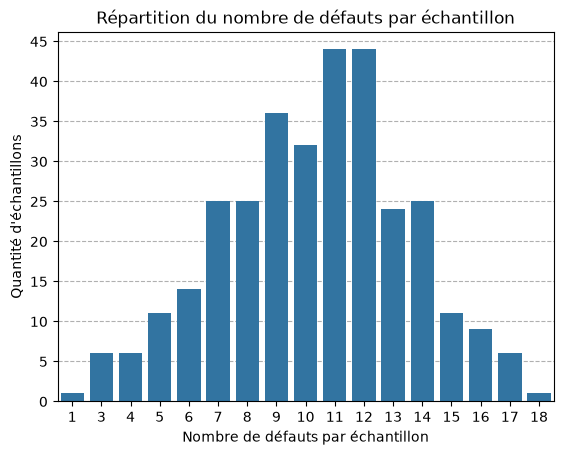

In [6]:
ax = sns.countplot(data=df, x="Defects")
plt.title("Répartition du nombre de défauts par échantillon")
plt.xlabel("Nombre de défauts par échantillon")
plt.ylabel("Quantité d'échantillons")
plt.yticks([0,5,10,15,20,25,30,35,40,45]) 
ax.set_axisbelow(True) 
ax.grid(axis="y", linestyle="--")

In [7]:
print(f"{(df["Defects"] < 5).sum()} échantillons ont une qualité remarquable avec moins de 5 défauts")

13 échantillons ont une qualité remarquable avec moins de 5 défauts


On observe que 50% des échantillons contiennent entre 8 et 12 défauts, avec un minimum de 1 et un maximum de 18 défauts. La moyenne est de 10,3 défauts et la médiane de 11 sur un total de 320 échantillons prélevés. 

In [105]:
df["Sample"].unique()

<StringArray>
['08:15', '08:30', '08:45', '09:00', '09:15', '09:30', '09:45', '10:00',
 '10:15', '10:30', '10:45', '11:00', '11:15', '11:30', '11:45', '12:00',
 '12:15', '12:30', '12:45', '13:00', '13:15', '13:30', '13:45', '14:00',
 '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45', '16:00']
Length: 32, dtype: str

In [116]:
df.groupby("Day")["Sample"].agg(["min", "max", "count"])

,min,max,count
Day,,,
1,08:15,16:00,32
2,08:15,16:00,32
3,08:15,16:00,32
4,08:15,16:00,32
5,08:15,16:00,32
6,08:15,16:00,32
7,08:15,16:00,32
8,08:15,16:00,32
9,08:15,16:00,32


### La production est-elle stable au fil des jours ?

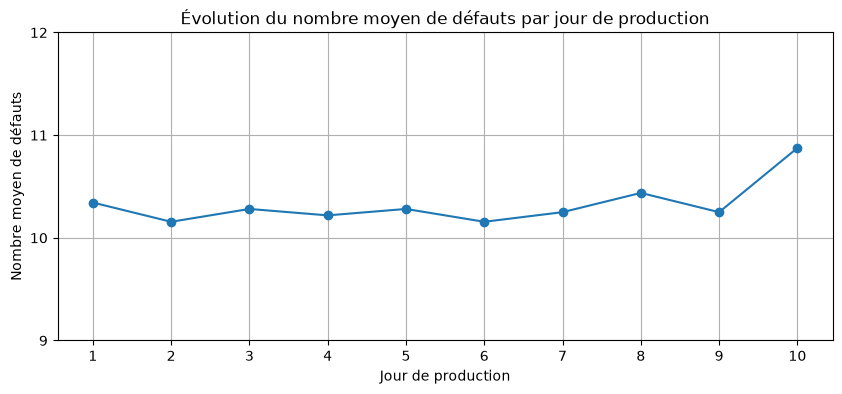

In [132]:
# Moyenne des défauts par jour de production
moyennes = df.groupby("Day")["Defects"].mean()
x = df["Day"].unique()

plt.figure(figsize=(10, 4))
plt.plot(moyennes.index, moyennes.values, marker="o")
plt.title("Évolution du nombre moyen de défauts par jour de production")
plt.xlabel("Jour de production")
plt.ylabel("Nombre moyen de défauts")
plt.xticks(x)
plt.yticks([9,10,11,12])
plt.grid(True)
plt.show()

In [128]:
df.groupby("Day")["Defects"].agg(Total=("sum"), Moyenne=("mean"), Minimum=("min"), Maximum=("max"), Nbr_de_prelevement=("count"))

,Total,Moyenne,Minimum,Maximum,Nbr_de_prelevement
Day,,,,,
1,331,10.34375,4,15,32
2,325,10.15625,1,17,32
3,329,10.28125,4,17,32
4,327,10.21875,3,16,32
5,329,10.28125,3,17,32
6,325,10.15625,4,17,32
7,328,10.25000,3,16,32
8,334,10.43750,3,17,32
9,328,10.25000,5,16,32


On n'observe pas de dérive au fil des jours, la qualité de la production est très stable

### La production est-elle stable au cours de la journée ? 

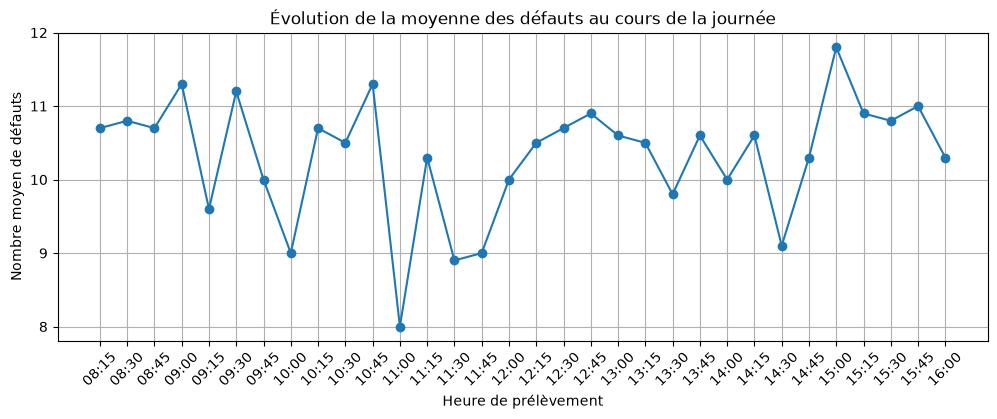

In [8]:
# Moyenne des défauts pour chaque créneau de 15 min, tous jours confondus
evolution_horaire = df.groupby("Sample")["Defects"].mean()

plt.figure(figsize=(12, 4))
plt.plot(evolution_horaire.index, evolution_horaire.values, marker="o")
plt.title("Évolution de la moyenne des défauts au cours de la journée")
plt.xlabel("Heure de prélèvement")
plt.ylabel("Nombre moyen de défauts")
plt.xticks(rotation=45)
plt.yticks([8,9,10,11,12])
plt.grid(True)
plt.show()

### La variabilité est-elle normale ou nécessite-t-elle une intervention corrective ?

J'utilise ici la carte de contrôle c, l'outil standard de la maîtrise statistique des procédés (SPC).

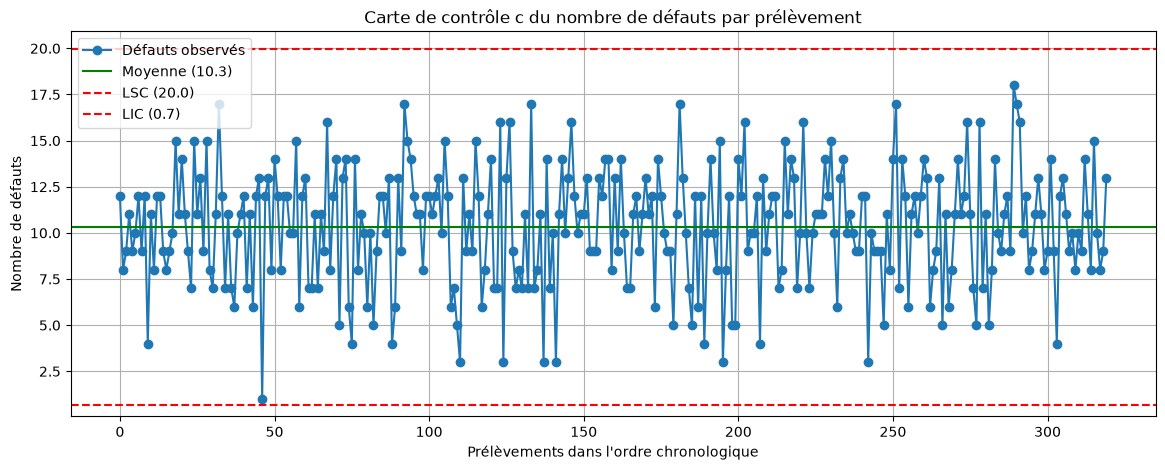

In [154]:
# Carte de contrôle c : nombre de défauts par prélèvement
c_bar = df["Defects"].mean()
lsc = c_bar + 3 * (c_bar ** 0.5)   # limite supérieure
lic = max(c_bar - 3 * (c_bar ** 0.5), 0)   # limite inférieure

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Defects"], marker="o", label="Défauts observés")
plt.axhline(c_bar, color="green", label=f"Moyenne ({c_bar:.1f})")
plt.axhline(lsc, color="red", linestyle="--", label=f"LSC ({lsc:.1f})")
plt.axhline(lic, color="red", linestyle="--", label=f"LIC ({lic:.1f})")
plt.title("Carte de contrôle c du nombre de défauts par prélèvement")
plt.xlabel("Prélèvements dans l'ordre chronologique")
plt.ylabel("Nombre de défauts")
plt.legend()
plt.grid(True)
plt.show()

Un processus dont tous les points restent dans les limites est dit "sous contrôle statistique" : les variations observées relèvent de la variabilité commune et ne justifient pas d'action corrective.